In [12]:
import shap
from utils.data_loader import load_folktables_income_data
import seaborn as sns
import numpy as np
np.random.seed(5)
from utils.sampling import  sample_with_test_set
from sklearn.preprocessing import StandardScaler
from utils.metrics import calculate_feature_importance, train_pu_classifier

In [13]:
df, columns, target = load_folktables_income_data()
df[columns] = StandardScaler().fit_transform(df[columns])
# N = df[df["label"] == 1]
# R = df[df["label"] == 0]
N, R, T = sample_with_test_set(
           "less_negative_class",
           df,
           target,
           train_fraction=0.5,
           bias_fraction=0.1,
           test_fraction=0.1,
           columns=columns,
       )

In [14]:
clf = train_pu_classifier(N[columns], N[target])
explainer = shap.TreeExplainer(clf, data=N[columns].values)
shap_values = explainer(T[columns], check_additivity=False)

 94%|=================== | 1509/1600 [00:12<00:00]       

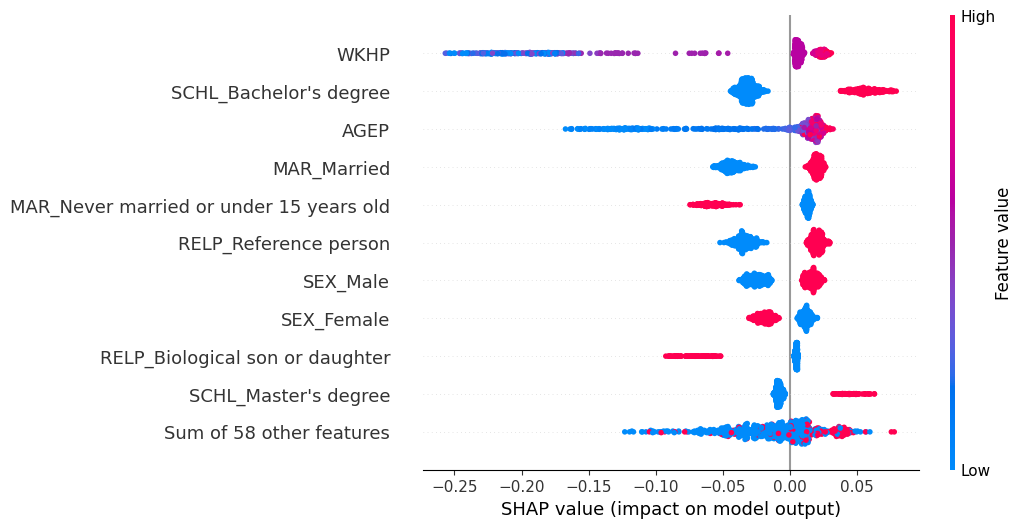

In [15]:
shap.plots.beeswarm(shap_values[:, :, 1], max_display=11)

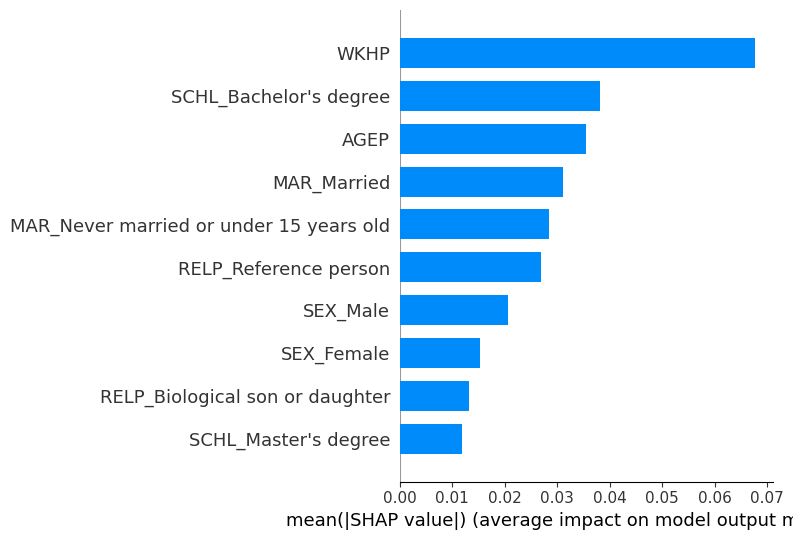

In [16]:
shap.summary_plot(shap_values[:, :, 1], plot_type="bar", max_display=10)